## Problem Statement
Social media platforms generate massive user feedback. This project aims to classify tweets into positive, negative, and neutral sentiments to help businesses understand customer opinions and improve decision-making.


In [78]:
!pip install nltk wordcloud

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import roc_curve

from wordcloud import WordCloud
import pickle

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [79]:
df = pd.read_csv("Tweets.csv")
df = df[['text','airline_sentiment']]
df.columns = ['text','target']

In [80]:
df.head()

,text,target
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [81]:
df['target'].value_counts()

,count
target,
negative,9178
neutral,3099
positive,2363


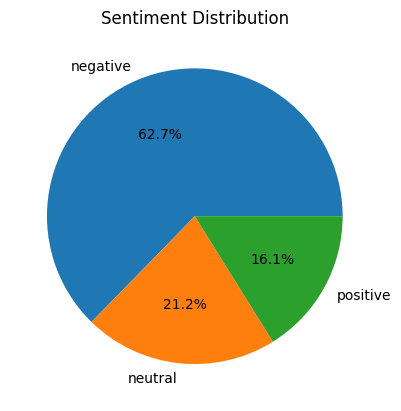

In [82]:
df['target'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.ylabel('')
plt.show()

In [83]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower().split()
    text = [ps.stem(word) for word in text if word not in stop_words]
    return " ".join(text)

df['clean_text'] = df['text'].apply(clean_text)

In [84]:
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [85]:
X = df['clean_text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [86]:
vectorizer = TfidfVectorizer(max_features=7000, ngram_range=(1,2))

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [87]:
cv_scores = cross_val_score(LogisticRegression(), X_train, y_train, cv=5)
print("CV Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

CV Scores: [0.77976953 0.78489117 0.77369769 0.77754056 0.79248506]
Mean CV Score: 0.7816768009657198


In [88]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
nb = MultinomialNB()
svm = LinearSVC()

lr.fit(X_train, y_train)
nb.fit(X_train, y_train)
svm.fit(X_train, y_train)

LinearSVC()

In [89]:
lr_pred = lr.predict(X_test)
nb_pred = nb.predict(X_test)
svm_pred = svm.predict(X_test)

In [90]:
print("Logistic:", accuracy_score(y_test, lr_pred))
print("Naive Bayes:", accuracy_score(y_test, nb_pred))
print("SVM:", accuracy_score(y_test, svm_pred))

Logistic: 0.7564890710382514
Naive Bayes: 0.7349726775956285
SVM: 0.7817622950819673


In [91]:
models = {
    "Logistic Regression": lr_pred,
    "Naive Bayes": nb_pred,
    "SVM": svm_pred
}

for name, preds in models.items():
    print(f"\n{name} Report:\n")
    print(classification_report(y_test, preds))


Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.90      0.78      0.84      1835
           1       0.53      0.69      0.60       614
           2       0.67      0.73      0.70       479

    accuracy                           0.76      2928
   macro avg       0.70      0.74      0.71      2928
weighted avg       0.78      0.76      0.77      2928


Naive Bayes Report:

              precision    recall  f1-score   support

           0       0.72      0.98      0.83      1835
           1       0.74      0.26      0.39       614
           2       0.87      0.41      0.55       479

    accuracy                           0.73      2928
   macro avg       0.78      0.55      0.59      2928
weighted avg       0.75      0.73      0.69      2928


SVM Report:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1835
           1       0.60      0.53      0.56       614
         

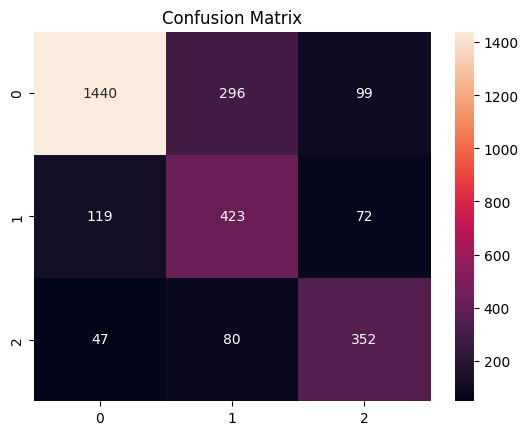

In [92]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

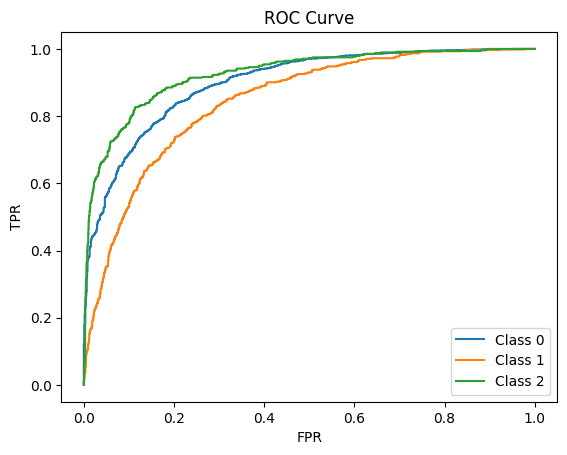

In [93]:
y_test_bin = label_binarize(y_test, classes=[0,1,2])
lr_probs = lr.decision_function(X_test)

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], lr_probs[:, i])
    plt.plot(fpr, tpr, label=f'Class {i}')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

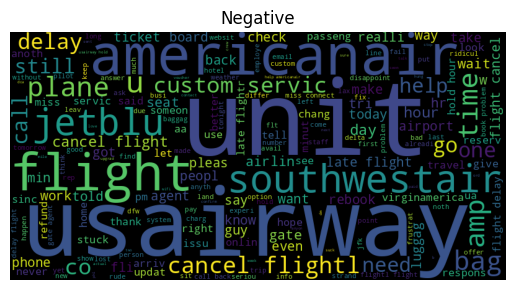

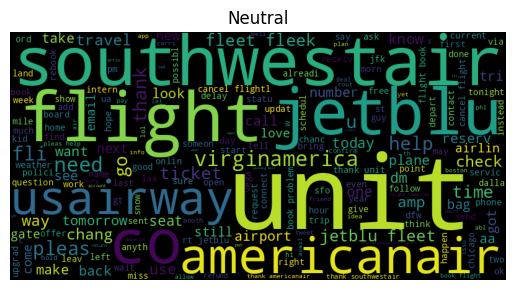

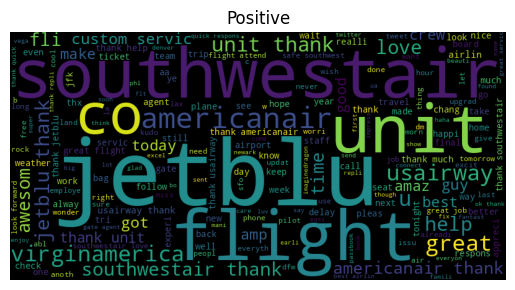

In [94]:
for i, label in enumerate(["Negative","Neutral","Positive"]):
    text = " ".join(df[df['target']==i]['clean_text'])
    wc = WordCloud(width=800, height=400).generate(text)

    plt.imshow(wc)
    plt.title(label)
    plt.axis('off')
    plt.show()


In [95]:
for i, label in enumerate(["Negative","Neutral","Positive"]):
    coefs = lr.coef_[i]
    top = sorted(zip(coefs, vectorizer.get_feature_names_out()), reverse=True)[:10]

    print(f"\nTop words for {label}:")
    for coef, word in top:
        print(word)


Top words for Negative:
hour
delay
worst
hold
hr
bag
luggag
noth
rude
suck

Top words for Neutral:
possibl
southwestair
jetblu
carri
hi
americanair
delay cancel
dm
need
polici

Top words for Positive:
thank
great
awesom
love
amaz
best
thx
appreci
good
kudo


In [96]:
def predict_sentiment(text):
    text_clean = clean_text(text)
    text_vec = vectorizer.transform([text_clean])

    probs = lr.predict_proba(text_vec)[0]
    pred = np.argmax(probs)
    confidence = max(probs)

    labels = ["Negative 😡","Neutral 😐","Positive 😊"]

    return labels[pred], round(confidence*100,2)

In [97]:
print(predict_sentiment("I love this airline"))
print(predict_sentiment("Worst service ever"))
print(predict_sentiment("It was okay"))

('Positive 😊', np.float64(86.69))
('Negative 😡', np.float64(90.63))
('Neutral 😐', np.float64(63.98))


In [101]:
while True:
    text = input("Enter tweet (or type exit): ")
    if text == "exit":
        break
    print(predict_sentiment(text))

Enter tweet (or type exit): flight was okay
('Neutral 😐', np.float64(65.33))
Enter tweet (or type exit): not bad at all
('Negative 😡', np.float64(83.06))
Enter tweet (or type exit): exit


In [102]:
errors = pd.DataFrame({
    "Text": X_test[:20],
    "Actual": y_test[:20],
    "Predicted": lr_pred[:20]
})

print(errors[errors["Actual"] != errors["Predicted"]])

                                                   Text  Actual  Predicted
6541  <Compressed Sparse Row sparse matrix of dtype ...       0          1


In [100]:
pickle.dump(lr, open("model.pkl","wb"))
pickle.dump(vectorizer, open("vectorizer.pkl","wb"))